In [ ]:
#Importing Necessary Libraries and Data

In [1]:
import numpy as np      # To use np.arrays
import pandas as pd     # To use dataframes
from pandas.plotting import autocorrelation_plot as auto_corr

# To plot
import matplotlib.pyplot as plt  
%matplotlib inline    
import matplotlib as mpl
import seaborn as sns
import plotly.express as px

#For date-time
import math
from datetime import datetime
from datetime import timedelta
#processing Libraries
from sklearn.model_selection import (TimeSeriesSplit,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     train_test_split, 
                                     KFold, 
                                     StratifiedKFold,
                                    cross_val_score)

from sklearn.preprocessing import (LabelEncoder,
                                   StandardScaler, 
                                   MinMaxScaler, 
                                   OrdinalEncoder)
from sklearn.svm import SVR
from sklearn.feature_selection import SelectFromModel

In [2]:
#importing Data
df=pd.read_csv("E:/Data Analytics/Sales_data/Walmart.csv" ,parse_dates=['Date'] )
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [57]:
df.tail(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,10-05-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,10-12-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [59]:
df.shape

(6435, 8)

In [60]:
df['Store'].nunique() # number of different values

45

In [3]:
store_dept_table = df.pivot_table(index='Store',
                                  values='Weekly_Sales', 
                                  aggfunc='mean')
display(store_dept_table)

,Weekly_Sales
Store,
1,1.555264e+06
2,1.925751e+06
3,4.027044e+05
4,2.094713e+06
5,3.180118e+05
6,1.564728e+06
7,5.706173e+05
8,9.087495e+05
9,5.439806e+05


In [33]:
df.loc[df['Weekly_Sales']<=0] #seen that there are some wrong values such as there are 0 and minus values for weekly sales

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment


In [62]:
df['Date'].head(5)# to see first and last 5 rows

0    02-05-2010
1    02-12-2010
2    19-02-2010
3    26-02-2010
4    03-05-2010
Name: Date, dtype: object

In [63]:
df['Date'].tail(5)

6430    28-09-2012
6431    10-05-2012
6432    10-12-2012
6433    19-10-2012
6434    26-10-2012
Name: Date, dtype: object

C:\Users\Ankita\AppData\Local\Temp\ipykernel_65632\2279145482.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df,palette='Set2')


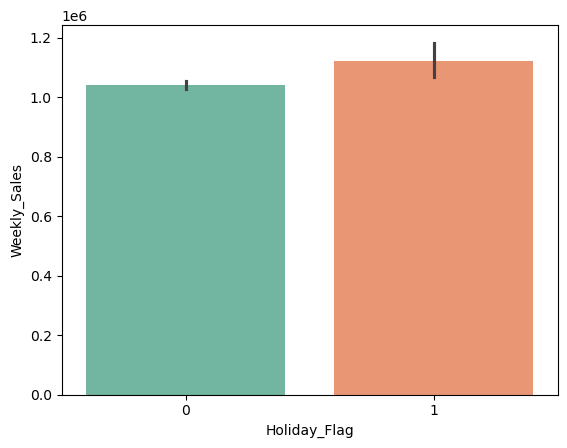

In [9]:
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df,palette='Set2')
plt.show()

In [65]:
df_holiday = df.loc[df['Holiday_Flag']==1]
df_holiday['Date'].unique() 

array(['02-12-2010', '09-10-2010', '26-11-2010', '31-12-2010',
       '02-11-2011', '09-09-2011', '25-11-2011', '30-12-2011',
       '02-10-2012', '09-07-2012'], dtype=object)

In [13]:
df_holiday = df.loc[df['Holiday_Flag']==0]
df_holiday['Date'].nunique()

57

In [20]:
# Super bowl dates in data set
df.loc[(df['Date'] == '02-12-2010')|(df['Date'] == '02-11-2011')|(df['Date'] == '02-10-2012'),'Super_Bowl'] = 1
df.loc[(df['Date'] != '02-12-2010')&(df['Date'] != '02-11-2011')&(df['Date'] != '02-10-2012'),'Super_Bowl'] = 0

In [13]:
# Labor day dates in data set
df.loc[(df['Date'] == '09-10-2010')|(df['Date'] == '09-09-2011')|(df['Date'] == '09-07-2012'),'Labor_Day'] = 1
df.loc[(df['Date'] != '09-10-2010')&(df['Date'] != '09-09-2011')&(df['Date'] != '09-07-2012'),'Labor_Day'] = 0

In [14]:
# Thanksgiving dates in data set
df.loc[(df['Date'] == '26-11-2010')|(df['Date'] == '25-11-2011'),'Thanksgiving'] = 1
df.loc[(df['Date'] != '26-11-2010')&(df['Date'] != '25-11-2011'),'Thanksgiving'] = 0

In [16]:
#Christmas dates in train set
df.loc[(df['Date'] == '31-12-2010')|(df['Date'] == '30-12-2011'),'Christmas'] = 1
df.loc[(df['Date'] != '31-12-2010')&(df['Date'] != '30-12-2011'),'Christmas'] = 0

In [70]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Super_Bowl,Labor_Day,Thanksgiving,Christmas
0,1,02-05-2010,1643690.90,0,42.31,2.572,211.096358,8.106,0.0,0.0,0.0,0.0
1,1,02-12-2010,1641957.44,1,38.51,2.548,211.242170,8.106,1.0,0.0,0.0,0.0
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106,0.0,0.0,0.0,0.0
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106,0.0,0.0,0.0,0.0
4,1,03-05-2010,1554806.68,0,46.50,2.625,211.350143,8.106,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684,0.0,0.0,0.0,0.0
6431,45,10-05-2012,733455.07,0,64.89,3.985,192.170412,8.667,0.0,0.0,0.0,0.0
6432,45,10-12-2012,734464.36,0,54.47,4.000,192.327265,8.667,0.0,0.0,0.0,0.0
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667,0.0,0.0,0.0,0.0


C:\Users\Ankita\AppData\Local\Temp\ipykernel_65632\2326021156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Christmas', y='Weekly_Sales', data=df,palette='Set2') # Christmas holiday vs not-Christmas


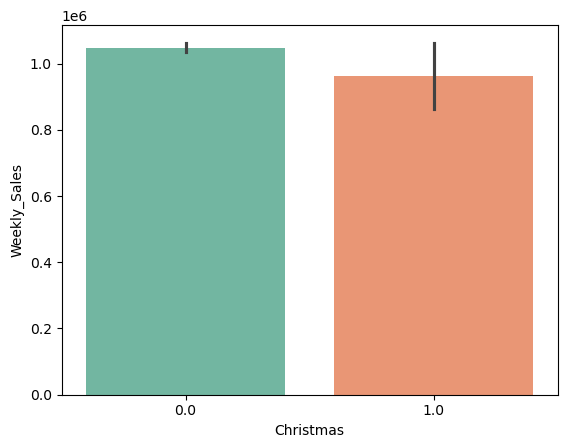

In [17]:
sns.barplot(x='Christmas', y='Weekly_Sales', data=df,palette='Set2') # Christmas holiday vs not-Christmas
plt.show()

C:\Users\Ankita\AppData\Local\Temp\ipykernel_65632\2533489119.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Thanksgiving', y='Weekly_Sales', data=df,palette='Set2') # Thanksgiving holiday vs not-thanksgiving


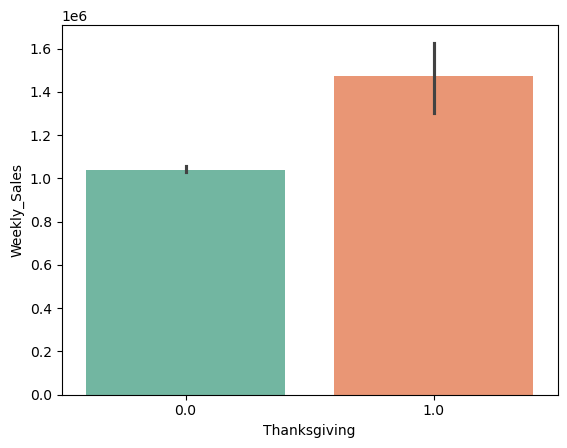

In [18]:
sns.barplot(x='Thanksgiving', y='Weekly_Sales', data=df,palette='Set2') # Thanksgiving holiday vs not-thanksgiving
plt.show()

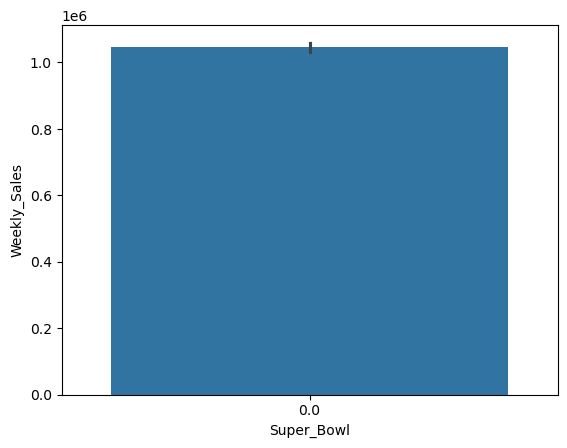

In [22]:
sns.barplot(x='Super_Bowl', y='Weekly_Sales', data=df) # Super bowl holiday vs not-super bowl
plt.show()

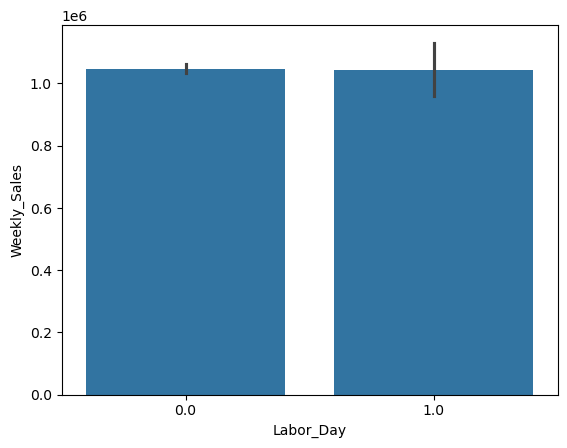

In [74]:
sns.barplot(x='Labor_Day', y='Weekly_Sales', data=df) # Labor day holiday vs not-labor day
plt.show()

In [75]:
df.groupby(['Christmas'])['Weekly_Sales'].mean() #Avg weekly sales on Chrismas

Christmas
0.0    1.048187e+06
1.0    9.608331e+05
Name: Weekly_Sales, dtype: float64

In [76]:
df.groupby(['Labor_Day'])['Weekly_Sales'].mean()  # Avg weekly sales on Labor Day

Labor_Day
0.0    1.047062e+06
1.0    1.042427e+06
Name: Weekly_Sales, dtype: float64

In [77]:
df.groupby(['Thanksgiving'])['Weekly_Sales'].mean()  # Avg weekly sales on Thanksgiving

Thanksgiving
0.0    1.040946e+06
1.0    1.471273e+06
Name: Weekly_Sales, dtype: float64

In [46]:
df.groupby(['Super_Bowl'])['Weekly_Sales'].mean()  # Avg weekly sales  on Super Bowl

Super_Bowl
0    1.046276e+06
1    1.079128e+06
Name: Weekly_Sales, dtype: float64

In [78]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

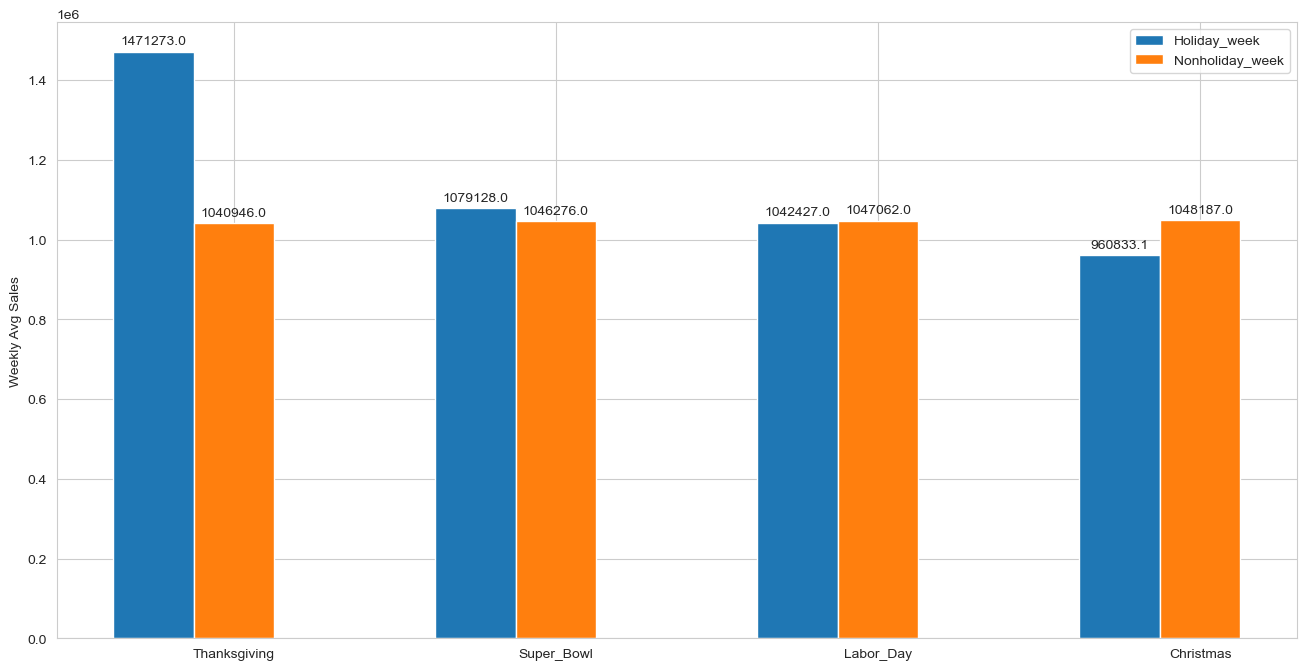

In [79]:
sns.set_style("whitegrid")
labels = ['Thanksgiving', 'Super_Bowl', 'Labor_Day', 'Christmas']
Holiday_week  = [1.471273e+06, 1.079128e+06, 1.042427e+06, 9.608331e+05]
Nonholiday_week  = [1.040946e+06, 1.046276e+06, 1.047062e+06, 1.048187e+06]

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(16, 8))
rects1 = ax.bar(x - width, Holiday_week, width, label='Holiday_week')
rects2 = ax.bar(x , Nonholiday_week, width, label='Nonholiday_week')

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Weekly Avg Sales')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

autolabel(rects1)
autolabel(rects2)

plt.show()

In [58]:
#for checking null
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Super_Bowl      0
Labor_Day       0
Thanksgiving    0
Christmas       0
dtype: int64

In [80]:
df.describe() # to see weird statistical things

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Super_Bowl,Labor_Day,Thanksgiving,Christmas
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,0.020979,0.020979,0.013986,0.013986
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.143325,0.143325,0.117442,0.117442
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,0.000000,0.000000,0.000000,0.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,0.000000,0.000000,0.000000,0.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,1.000000,1.000000,1.000000,1.000000


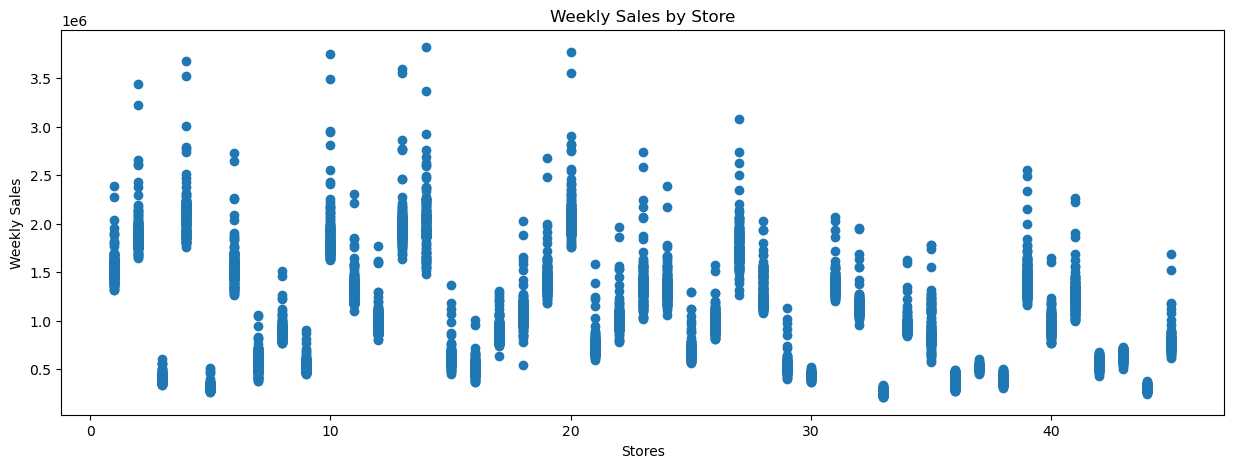

In [23]:
x = df['Store']
y = df['Weekly_Sales']
plt.figure(figsize=(15,5))
plt.title('Weekly Sales by Store')
plt.xlabel('Stores')
plt.ylabel('Weekly Sales')
plt.scatter(x,y)
plt.show()

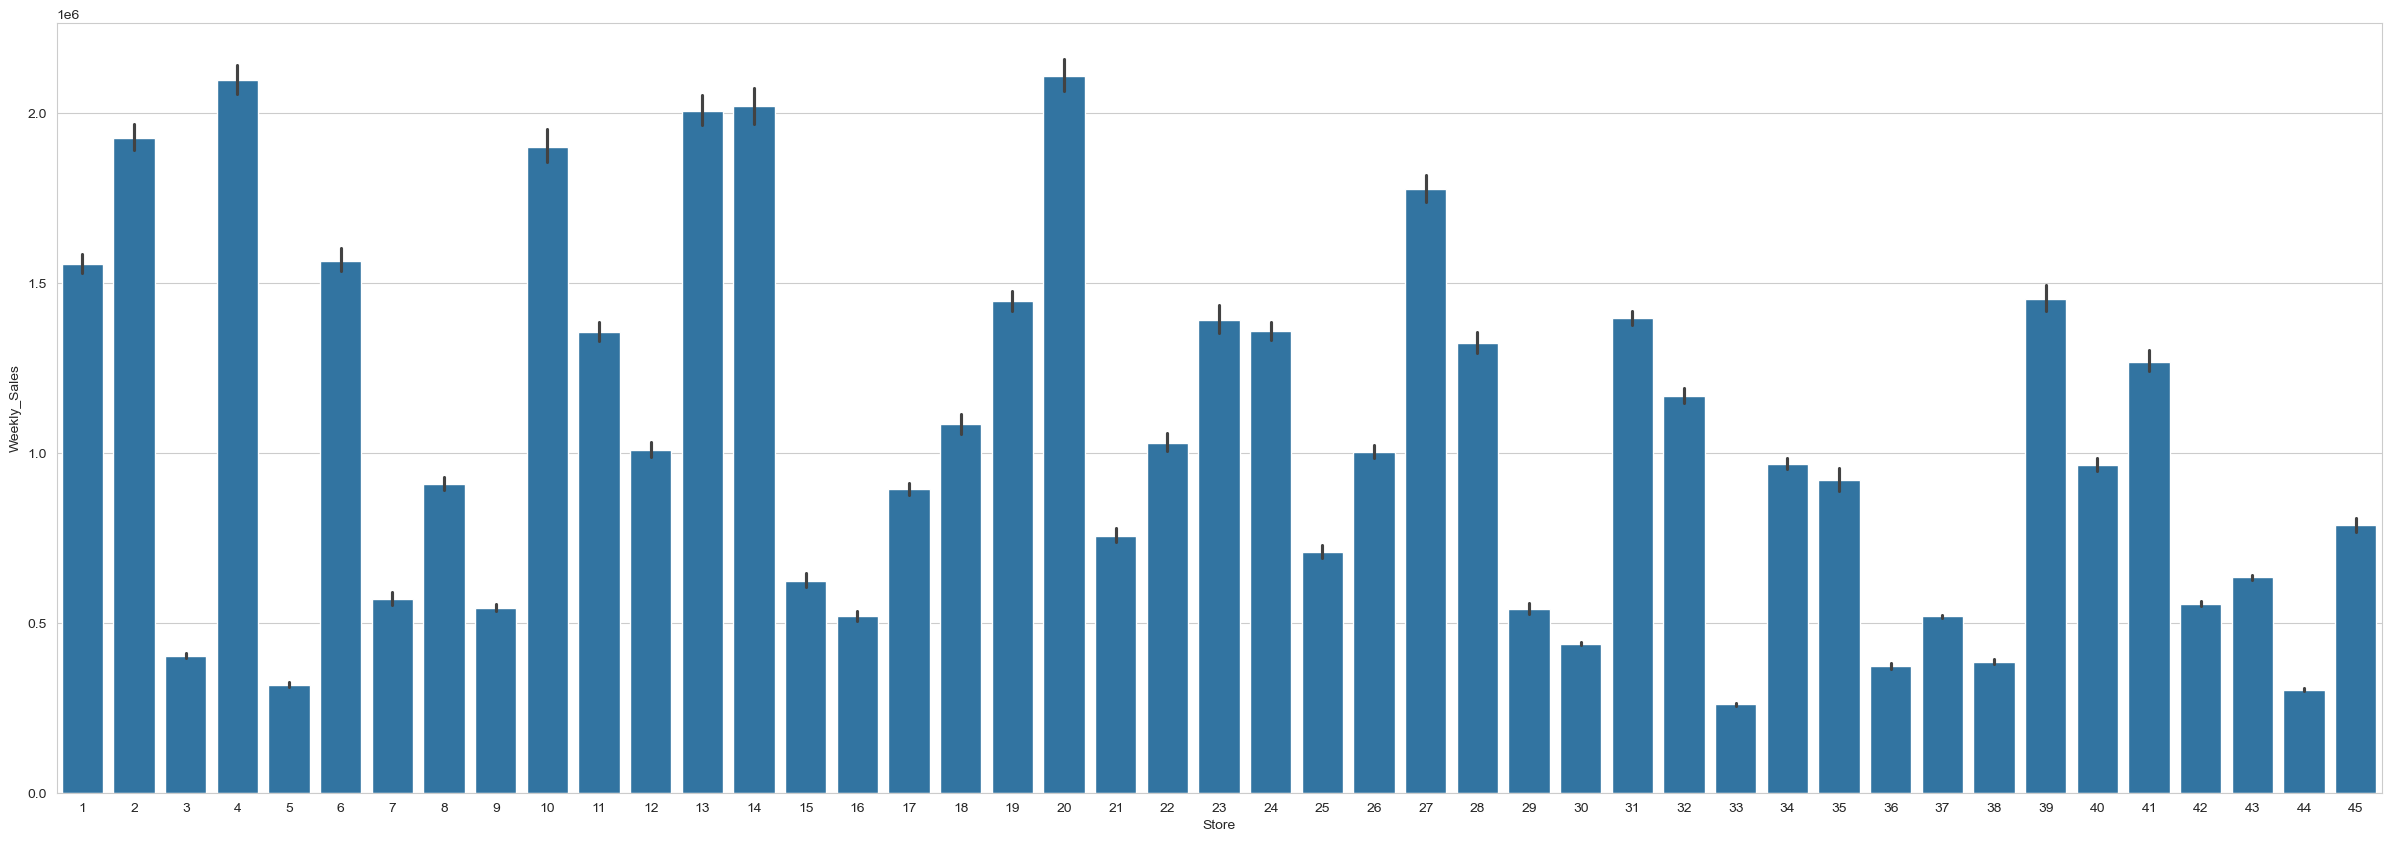

In [82]:
plt.figure(figsize=(30,10))
fig = sns.barplot(x='Store', y='Weekly_Sales', data=df)
plt.show()

####Finding the Unique value from Categorical data

In [86]:
for i in ['Store','Fuel_Price','Unemployment']:#,'Day','Month','Year']:
    print(f'{i}: {df[i].nunique()}')

Store: 45
Fuel_Price: 892
Unemployment: 349


In [28]:
# GETTING THE DATA TYPES+
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
 8   Super_Bowl    6435 non-null   float64
 9   Labor_Day     6435 non-null   float64
 10  Thanksgiving  6435 non-null   float64
 11  Christmas     6435 non-null   float64
dtypes: float64(9), int64(2), object(1)
memory usage: 603.4+ KB


In [29]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y') #convert the date format

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Super_Bowl    6435 non-null   float64       
 9   Labor_Day     6435 non-null   float64       
 10  Thanksgiving  6435 non-null   float64       
 11  Christmas     6435 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(2)
memory usage: 603.4 KB


#EXPLORATORY DATA ANALYSIS(EDA)

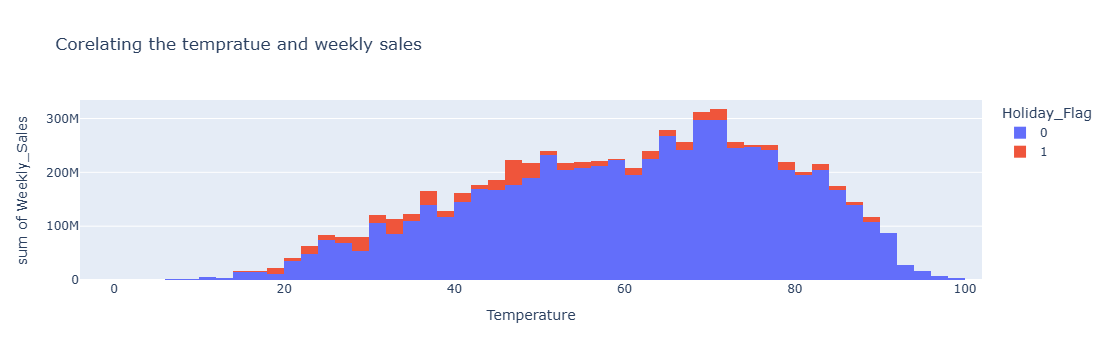

In [24]:
fig = px.histogram(df, x='Temperature', y ='Weekly_Sales', color='Holiday_Flag',title='Corelating the tempratue and weekly sales')
fig.show() 

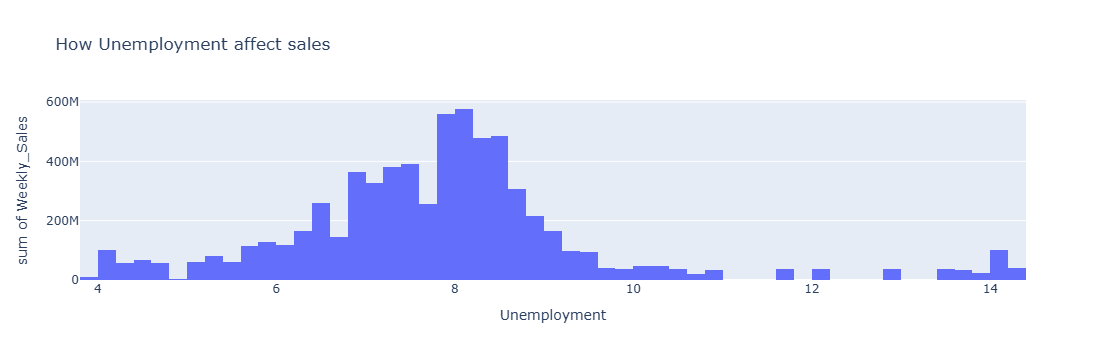

In [103]:
fig = px.histogram(df, x='Unemployment', y ='Weekly_Sales' ,title = 'How Unemployment affect sales')

fig.show()

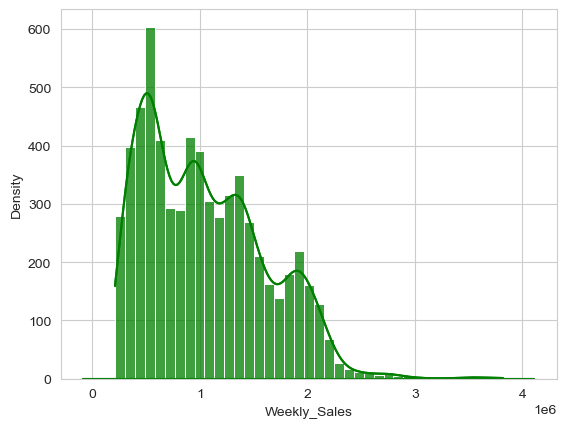

In [111]:
sns.histplot(df['Weekly_Sales'],kde=True, color="g")
plt.show()

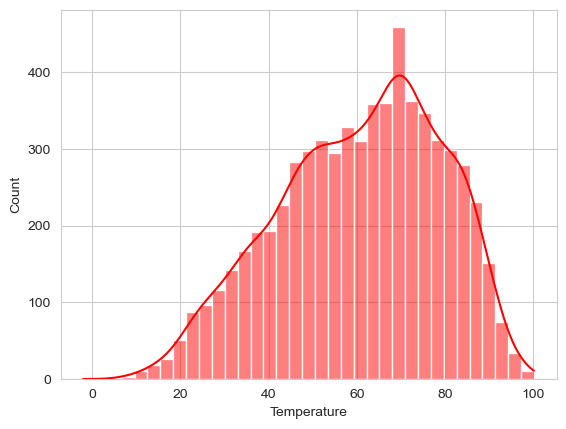

In [118]:
sns.histplot(df['Temperature'],kde=True,color = 'r')#, ax=axes[1])
plt.show()

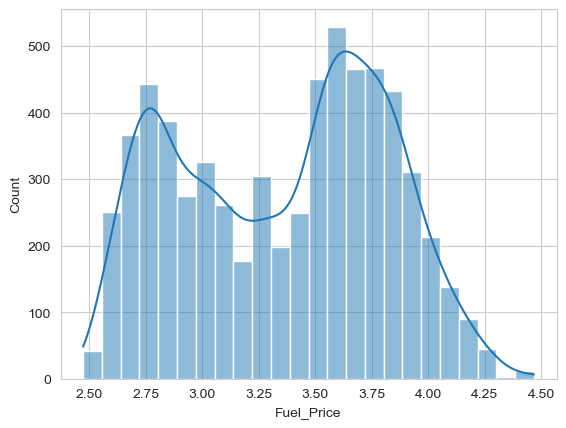

In [116]:
sns.histplot(df['Fuel_Price'],kde=True)
plt.show()

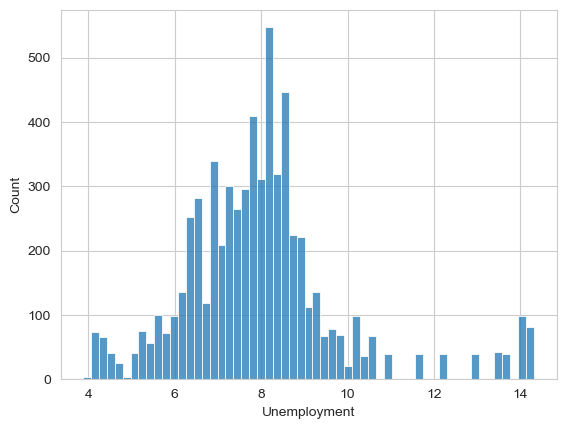

In [117]:
sns.histplot(df['Unemployment'],kde=False)
plt.show()

Performing some analysis using TIMESERIES factor

In [31]:
df['Year'] = df.Date.dt.year
df['Month'] = df.Date.dt.month
df['Day'] = df.Date.dt.day
df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [32]:
days = {0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5: 'Friday',6:'Saturday'}
df['Day'] = df['Day'].map(days)
months={1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October',11:'Novemenber',12:'December'}
df['Month']= df['Month'].map(months)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Super_Bowl,Labor_Day,Thanksgiving,Christmas,Year,Month,Day,WeekOfYear
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,0.0,0.0,0.0,0.0,2010,February,Friday,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,0.0,0.0,0.0,0.0,2010,February,NaN,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,0.0,0.0,0.0,0.0,2010,February,NaN,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,0.0,0.0,0.0,0.0,2010,February,NaN,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,0.0,0.0,0.0,0.0,2010,March,Friday,9


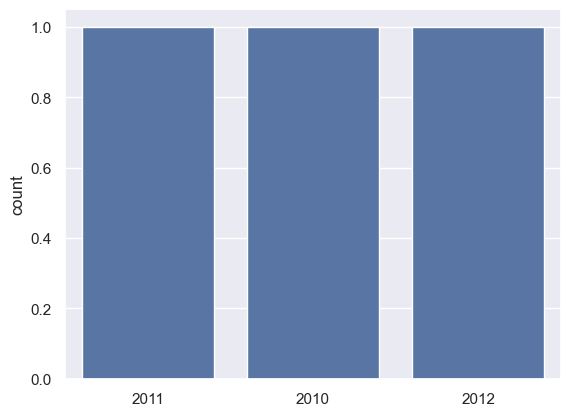

In [48]:
sns.countplot(df['Year'],order=df['Year'].value_counts().index)
plt.show()

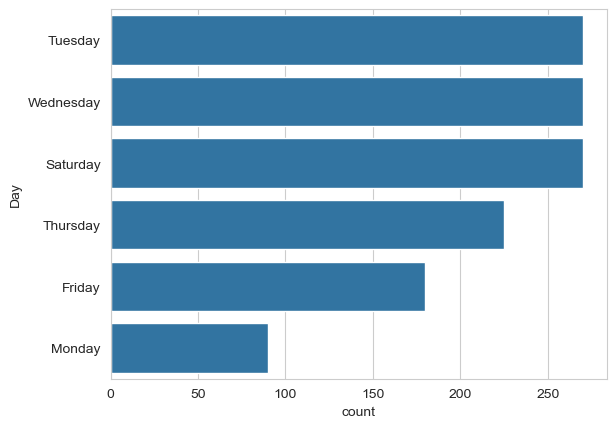

In [132]:
sns.countplot(df['Day'],order=df['Day'].value_counts().index)
plt.show()

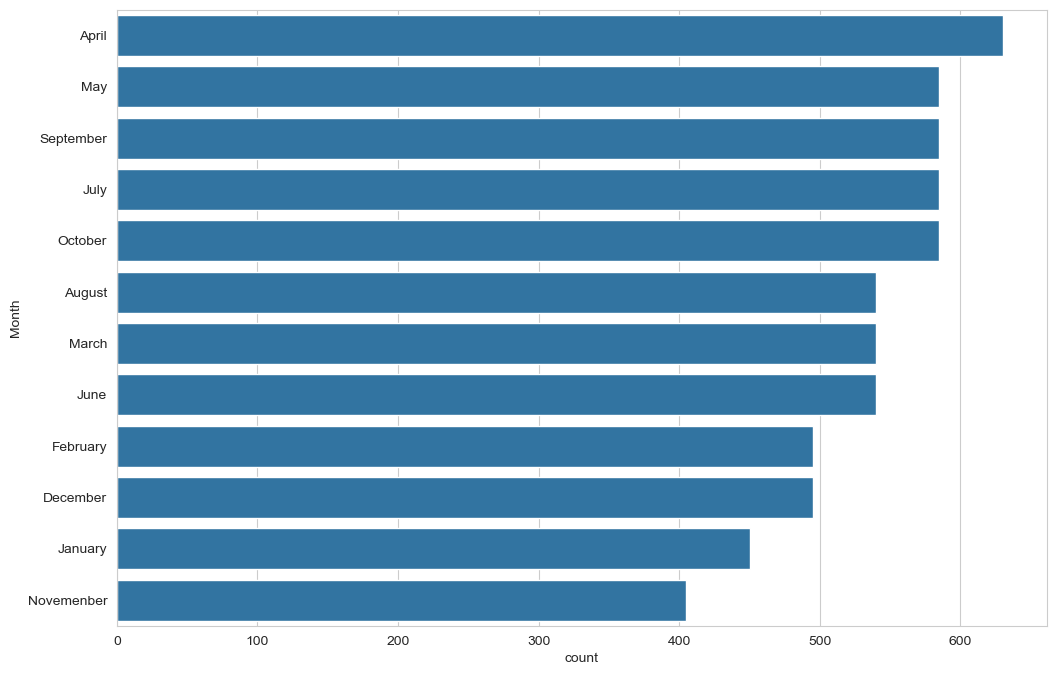

In [128]:
plt.figure(figsize=(12,8))
sns.countplot(df['Month'],order= df['Month'].value_counts().index)
plt.show()

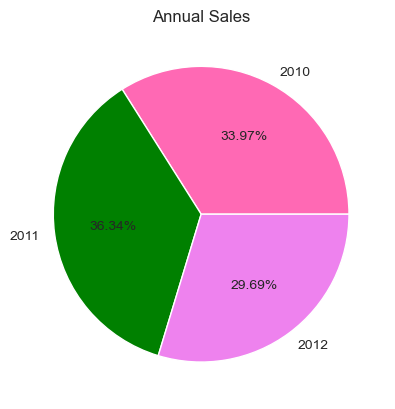

In [129]:
plt.pie(df.groupby('Year')['Weekly_Sales'].sum(),labels=df['Year'].unique(),normalize=True,autopct='%1.2f%%',colors=['hotpink','green','violet'])
plt.title('Annual Sales')
plt.show()

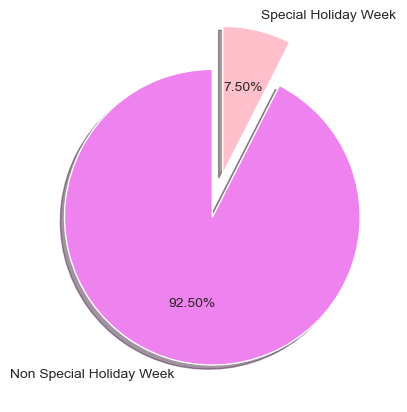

In [133]:
df4 = df.groupby('Holiday_Flag')['Weekly_Sales'].sum().reset_index()
plt.pie(df4['Weekly_Sales'],labels= ['Non Special Holiday Week','Special Holiday Week'],normalize=True,autopct='%1.2f%%',startangle=90,explode=[0,0.3],shadow=True,colors=['violet','pink'])
plt.show()

In [36]:
df.groupby('Month')['Weekly_Sales'].mean()

Month
April         1.026762e+06
August        1.048017e+06
December      1.281864e+06
February      1.053200e+06
January       9.238846e+05
July          1.031748e+06
June          1.064325e+06
March         1.013309e+06
May           1.031714e+06
Novemenber    1.147266e+06
October       9.996321e+05
September     9.893353e+05
Name: Weekly_Sales, dtype: float64

In [37]:
df.groupby('Year')['Weekly_Sales'].mean() # to see the best years for sales

Year
2010    1.059670e+06
2011    1.046239e+06
2012    1.033660e+06
Name: Weekly_Sales, dtype: float64

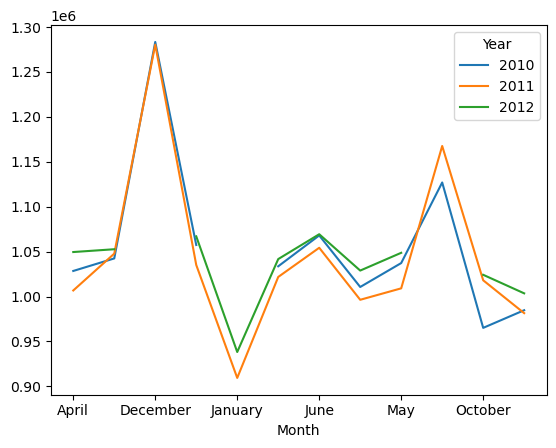

In [38]:
monthly_sales = pd.pivot_table(df, values = "Weekly_Sales", columns = "Year", index = "Month")
monthly_sales.plot()
plt.show()

From the graph, it is seen that 2011 has lower sales than 2010 generally. When we look at the mean sales it is seen that 2010 has higher values, but 2012 has no information about November and December which have higher sales. Despite of 2012 has no last two months sales, it's mean is near to 2010. Most probably, it will take the first place if we get 2012 results and add them.

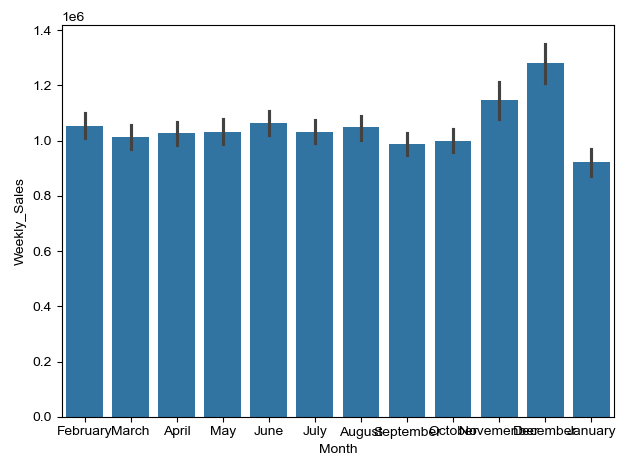

In [42]:
fig = sns.barplot(x='Month', y='Weekly_Sales', data=df)
plt.tight_layout()
sns.set_theme()
plt.show()

In [45]:
df.groupby('WeekOfYear')['Weekly_Sales'].mean().sort_values(ascending=False).head()

WeekOfYear
51    1.754774e+06
47    1.471273e+06
50    1.354517e+06
49    1.235866e+06
48    1.103329e+06
Name: Weekly_Sales, dtype: float64

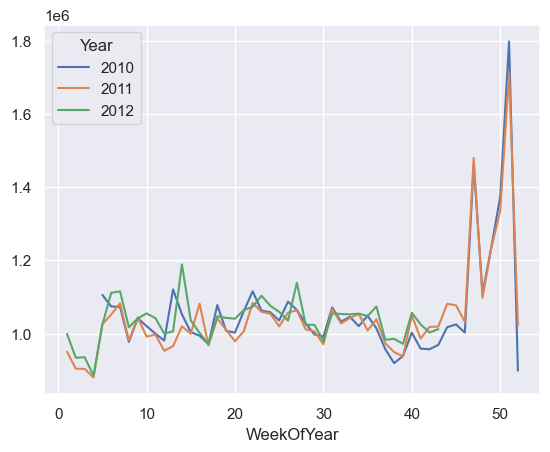

In [46]:
weekly_sales = pd.pivot_table(df, values = "Weekly_Sales", columns = "Year", index = "WeekOfYear")
weekly_sales.plot()
plt.show()

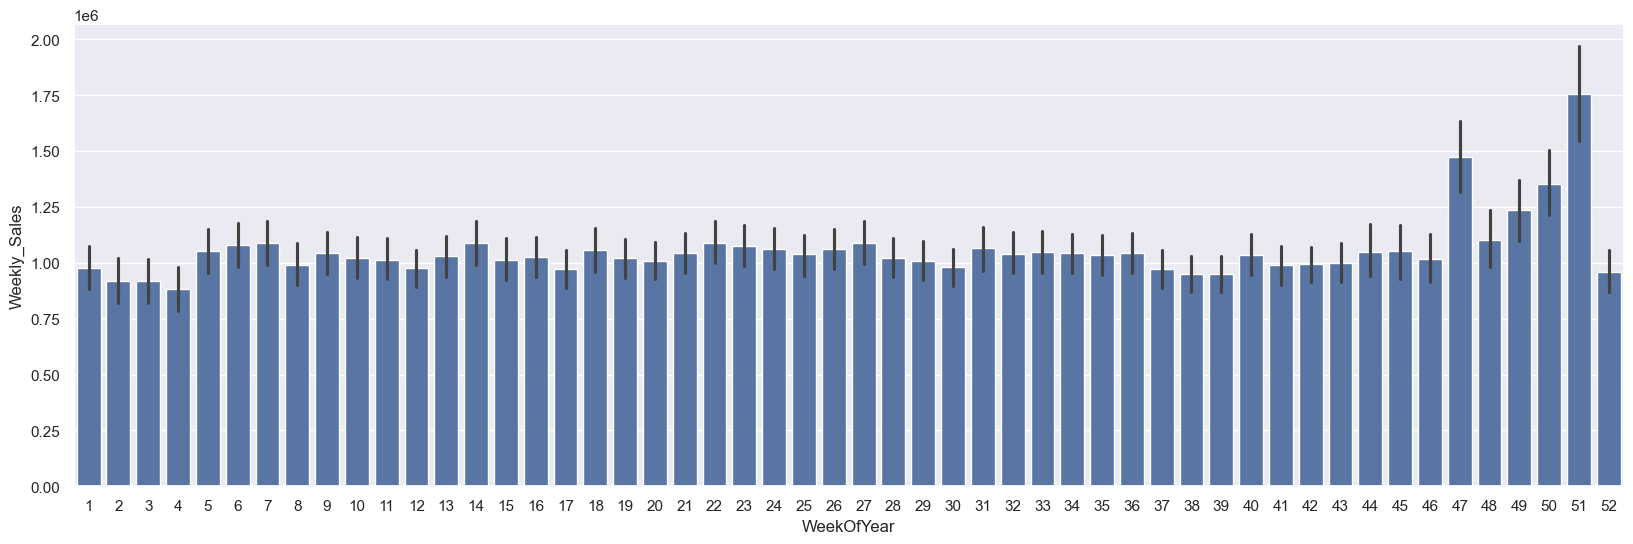

In [47]:
plt.figure(figsize=(20,6))
fig = sns.barplot(x='WeekOfYear', y='Weekly_Sales', data=df)
plt.show()